<a href="https://colab.research.google.com/github/pmatkowska94/MSC_Data_Science/blob/main/iPSC_EDA_%2B_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [ ]:
colours = {
    'hist_bar': '#4C9F70',
    'line_exp': '#1B9E77',
    'line_model': '#377EB8',
    'ci_fill': '#A6CEE3',
    'axes': '#333333',
    'grid': '#E5E5E5',
    'background': '#FFFFFF',
    'text': '#222222'
}

In [ ]:
plt.rcParams.update({
    'figure.facecolor': colours['background'],
    'axes.facecolor': colours['background'],
    'axes.edgecolor': colours['axes'],
    'axes.labelcolor': colours['text'],
    'xtick.color': colours['text'],
    'ytick.color': colours['text'],
    'grid.color': colours['grid'],
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'text.color': colours['text'],
    'axes.titlecolor': colours['text'],
})

In [ ]:
sns.set_style('whitegrid', {
    'axes.facecolor': '#FFFFFF',
    'grid.color': '#E5E5E5',
    'axes.edgecolor': '#333333',
    'text.color': '#222222'
})

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CSV Data Main Study iPSC.csv to CSV Data Main Study iPSC.csv


In [ ]:
df = pd.read_csv('CSV Data Main Study iPSC.csv')
df.head()

,Vessel,Process_ID,Run_ID,Clone_ID,time [day],VCD [10 ^6 cells/mL],Volume [L],Agitation [rpm],P/V [W/m^3],VVM (air/max_vol),...,Number of impellers,group_volume,Seeding density [10^6 cells/mL],cell_type,GLC [mmol/L],GLN [mmol/L],NH3 [mmol/L],LAC [mmol/L],Na [mmol/L],Osmo [mOsm/kg]
0,Applikon 0.5L,1.0,1.0,PN12.48,0.000000,0.3000,0.150,105.0,0.915912,0.0,...,2.0,0.5,0.3,ipsc,NaN,NaN,NaN,NaN,NaN,NaN
1,Applikon 0.5L,1.0,1.0,PN12.48,1.000000,0.0446,0.153,105.0,0.897953,0.0,...,2.0,0.5,0.3,ipsc,NaN,NaN,NaN,NaN,NaN,NaN
2,Applikon 0.5L,1.0,1.0,PN12.48,1.791667,0.0698,0.156,105.0,0.880684,0.0,...,2.0,0.5,0.3,ipsc,NaN,NaN,NaN,NaN,NaN,NaN
3,Applikon 0.5L,1.0,1.0,PN12.48,2.809167,0.3040,0.165,110.0,0.957351,0.0,...,2.0,0.5,0.3,ipsc,NaN,NaN,NaN,NaN,NaN,NaN
4,Applikon 0.5L,1.0,1.0,PN12.48,3.906250,0.6090,0.185,120.0,1.108534,0.0,...,2.0,0.5,0.3,ipsc,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.rename(columns={
    'Vessel': 'vessel',
    'Process_ID': 'p_id',
    'Run_ID' : 'r_id',
    'Clone_ID': 'clone_id',
    'time [day]': 'time',
    'VCD [10 ^6 cells/mL]': 'vcd',
    'Volume [L]': 'volume',
    'Agitation [rpm]': 'agitation',
    'P/V [W/m^3]': 'p_v',
    'VVM (air/max_vol)': 'vvm',
    'kLa [1/h]': 'kla',
    'impeller diameter [cm]': 'impeller_d',
    'Tip speed [m/s]': 'tip_speed',
    'Aspect_ratio': 'aspect_r',
    'DO [%]': 'do',
    'Reynolds': 'reynolds',
    'Np' : 'np',
    'Number of impellers' : 'impeller_no',
    'Seeding density [10^6 cells/mL]' : 'seed_d',
    'GLC [mmol/L]' : 'glc',
    'GLN [mmol/L]' : 'gln',
    'NH3 [mmol/L]' : 'nh3',
    'LAC [mmol/L]' : 'lac',
    'Na [mmol/L]' : 'na',
    'Osmo [mOsm/kg]' : 'osmo'
}, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   vessel        119 non-null    object 
 1   p_id          119 non-null    float64
 2   r_id          119 non-null    float64
 3   clone_id      119 non-null    object 
 4   time          119 non-null    float64
 5   vcd           119 non-null    float64
 6   volume        119 non-null    float64
 7   agitation     119 non-null    float64
 8   p_v           119 non-null    float64
 9   vvm           119 non-null    float64
 10  kla           0 non-null      float64
 11  impeller_d    119 non-null    float64
 12  tip_speed     119 non-null    float64
 13  reynolds      119 non-null    float64
 14  aspect_r      119 non-null    float64
 15  do            119 non-null    float64
 16  np            119 non-null    float64
 17  impeller_no   119 non-null    float64
 18  group_volume  119 non-null    

In [ ]:
df.describe()

,p_id,r_id,time,vcd,volume,agitation,p_v,vvm,kla,impeller_d,...,do,np,impeller_no,group_volume,seed_d,glc,gln,nh3,na,osmo
count,119.0,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,0.0,119.000000,...,119.0,119.000000,119.000000,119.000000,119.000000,83.000000,31.000000,31.000000,31.000000,82.000000
mean,1.0,7.865546,4.323452,3.854829,381.489252,105.218487,1.809388,0.006563,NaN,4.000000,...,30.0,1.375966,1.731092,1.827731,0.479546,26.060241,2.332258,1.738710,137.351613,359.343902
std,0.0,4.487127,3.134892,5.711636,880.190355,15.944373,1.113284,0.008586,NaN,1.993039,...,0.0,0.174445,0.445267,2.213630,0.330047,17.177786,1.130306,1.116147,21.015294,61.002862
min,1.0,1.000000,0.000000,0.031000,0.100000,70.000000,0.696890,0.000000,NaN,2.800000,...,30.0,1.000000,1.000000,0.500000,0.132000,2.400000,1.100000,0.100000,98.700000,219.000000
25%,1.0,4.000000,1.788125,0.470000,0.182500,91.500000,0.956181,0.000000,NaN,2.800000,...,30.0,1.340000,1.000000,0.500000,0.251000,12.400000,1.500000,0.700000,122.500000,306.425000
50%,1.0,8.000000,4.000000,1.190000,3.450000,105.000000,1.704000,0.005000,NaN,2.800000,...,30.0,1.500000,2.000000,0.500000,0.360000,21.700000,1.800000,1.800000,138.600000,355.000000
75%,1.0,11.500000,6.376667,5.670000,190.000000,115.000000,2.120000,0.010000,NaN,7.000000,...,30.0,1.500000,2.000000,5.000000,0.642000,35.500000,3.250000,2.750000,146.500000,388.500000
max,1.0,16.000000,13.000000,33.750000,4500.000000,135.000000,5.424956,0.041000,NaN,7.600000,...,30.0,1.500000,2.000000,6.000000,1.500000,73.000000,4.700000,3.500000,181.400000,521.000000


In [ ]:
df.nunique()

,0
vessel,4
p_id,1
r_id,16
clone_id,1
time,71
vcd,112
volume,82
agitation,21
p_v,88
vvm,16


In [ ]:
df.isnull().sum()

,0
vessel,1
p_id,1
r_id,1
clone_id,1
time,1
vcd,1
volume,1
agitation,1
p_v,1
vvm,1


<Axes: >

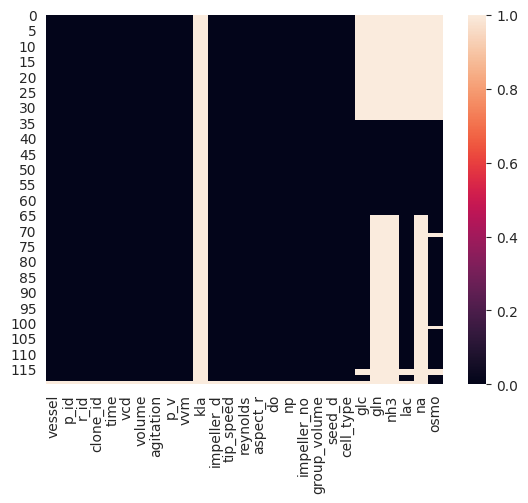

In [ ]:
sns.heatmap(df.isnull())

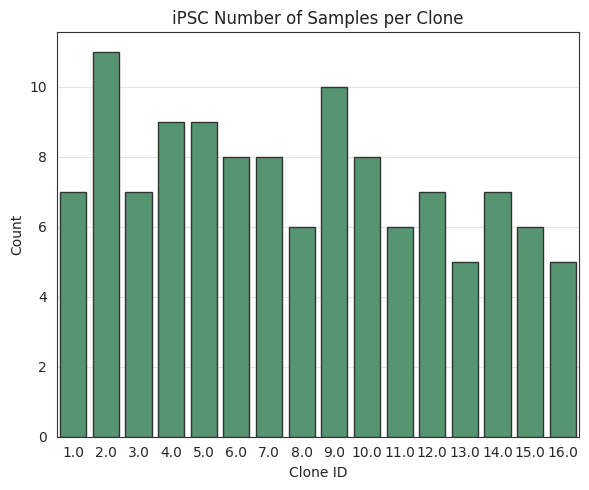

In [ ]:
plt.figure(figsize=(6,5))
sns.countplot(
    x='r_id',
    data=df,
    color=colours['hist_bar'],
    edgecolor=colours['axes']
)
plt.xlabel('Clone ID', color=colours['text'])
plt.ylabel('Count', color=colours['text'])
plt.title('iPSC Number of Samples per Clone', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

**Length of each run:** There are some longer runs.

In [ ]:
pd.crosstab(df['r_id'], df['group_volume'])

group_volume,0.5,5.0,6.0
r_id,,,
1.0,7,0,0
2.0,11,0,0
3.0,7,0,0
4.0,9,0,0
5.0,9,0,0
6.0,0,0,8
7.0,8,0,0
8.0,0,0,6
9.0,10,0,0


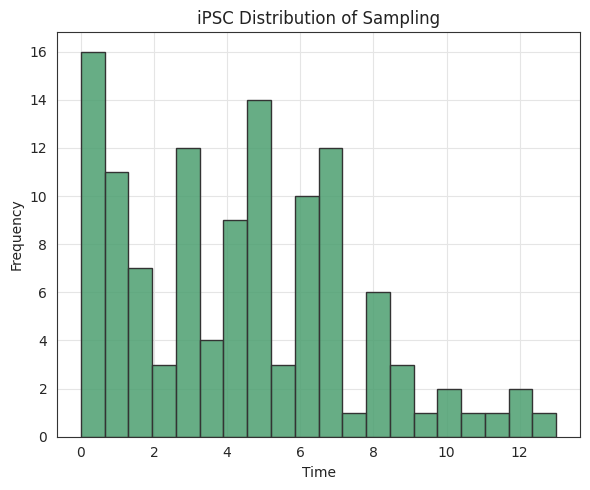

In [ ]:
plt.figure(figsize=(6,5))
sns.histplot(
    df['time'],
    bins=20,
    color=colours['hist_bar'],
    edgecolor=colours['axes'],
    alpha=0.85
)
plt.xlabel('Time', color=colours['text'])
plt.ylabel('Frequency', color=colours['text'])
plt.title('iPSC Distribution of Sampling', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

/tmp/ipython-input-422412046.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(6, 5))


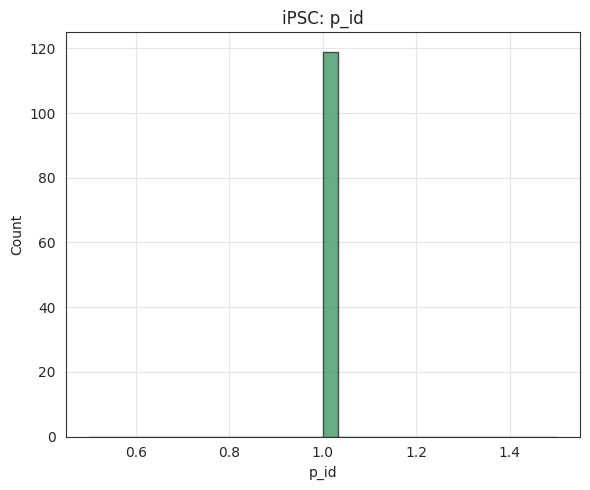

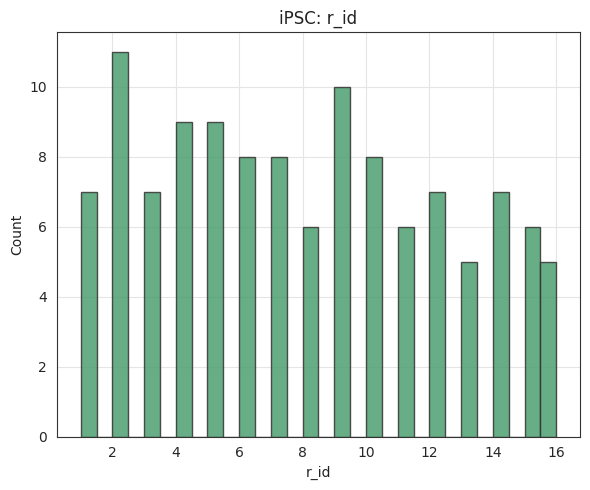

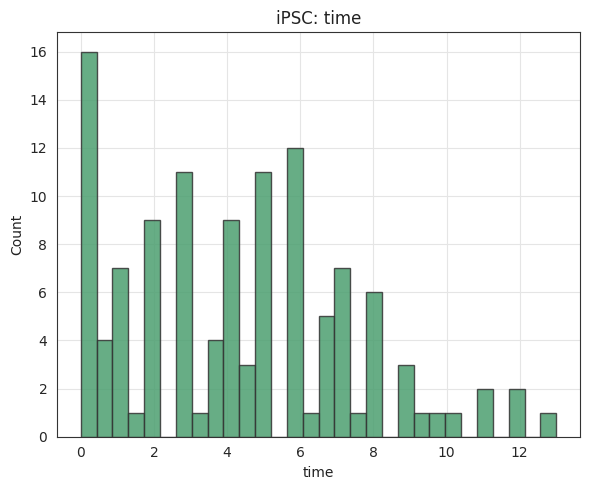

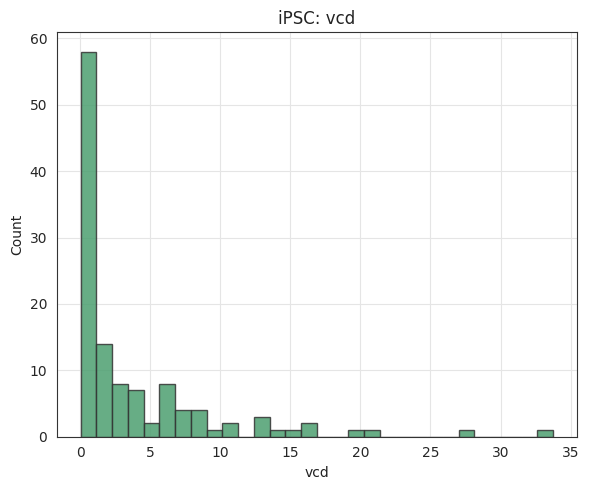

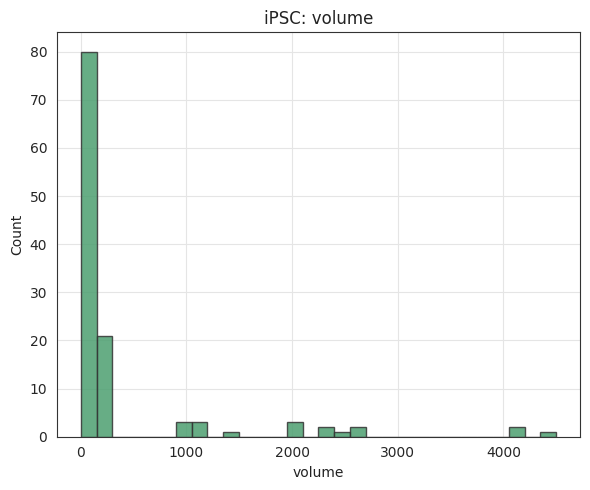

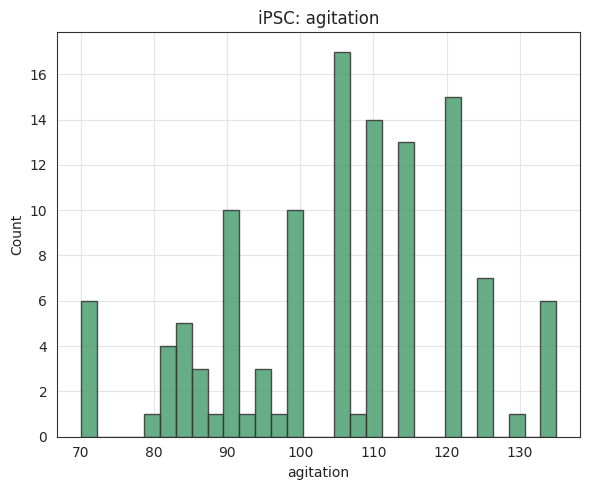

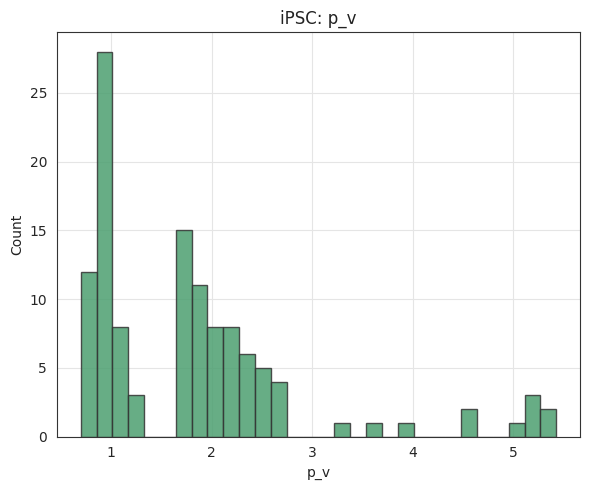

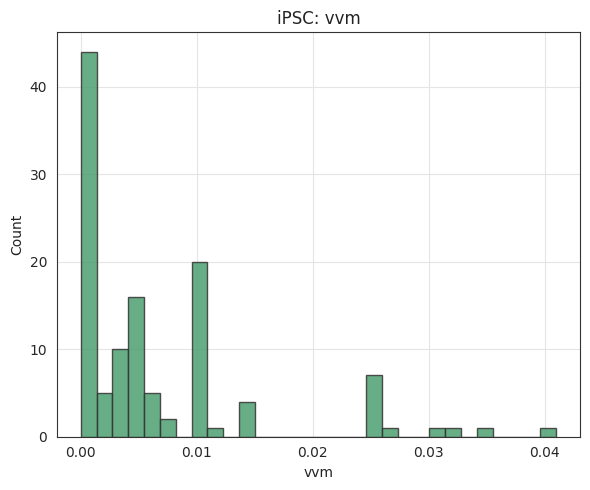

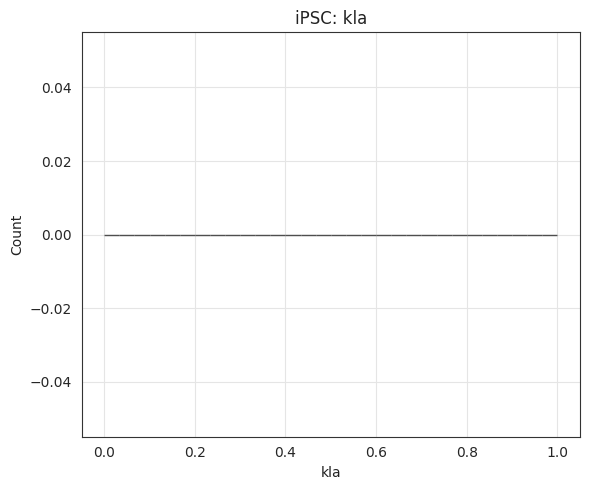

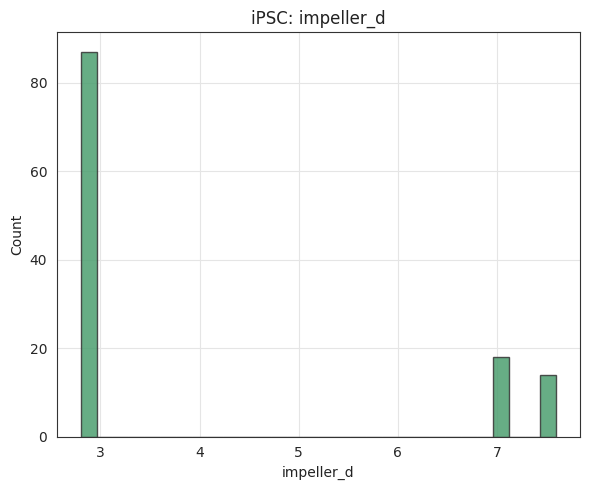

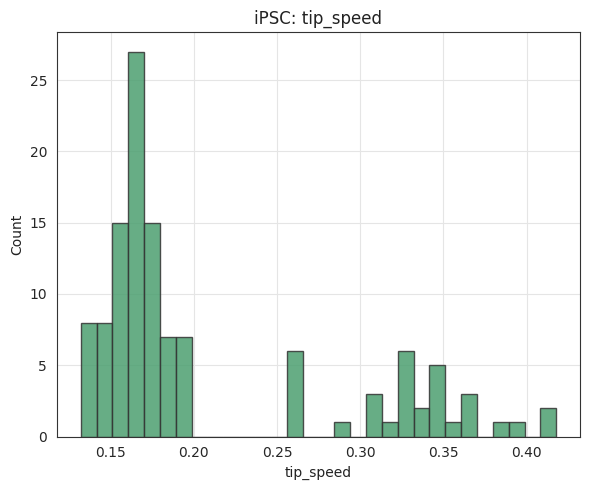

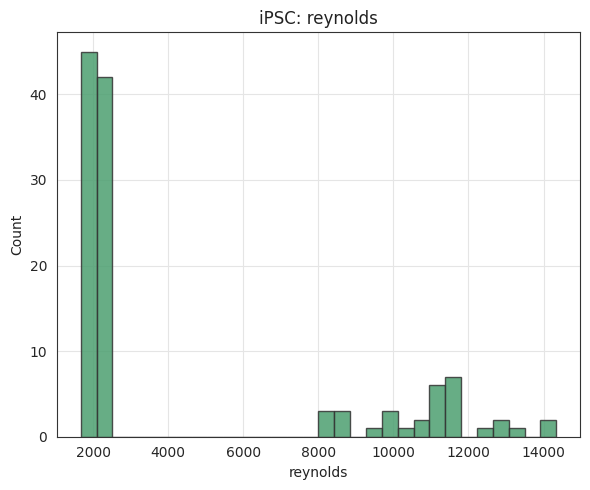

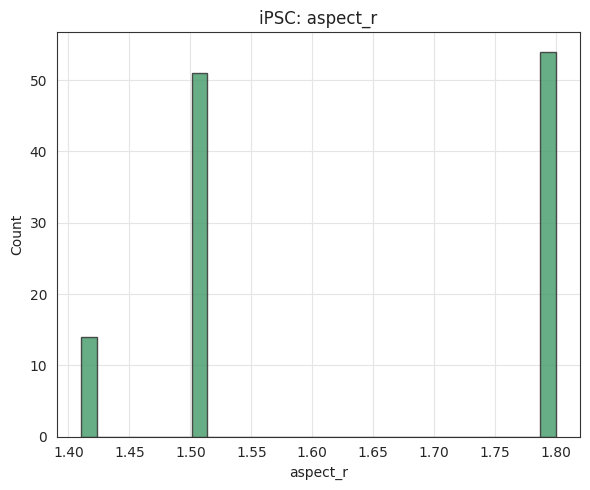

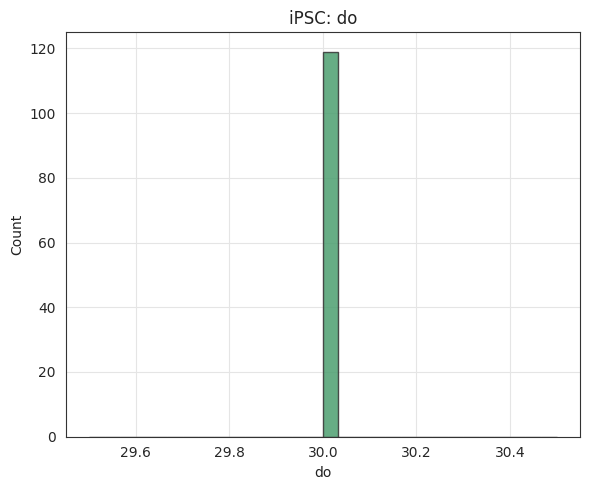

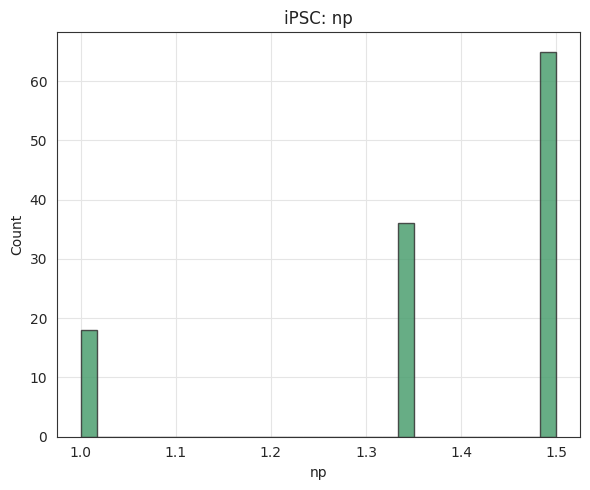

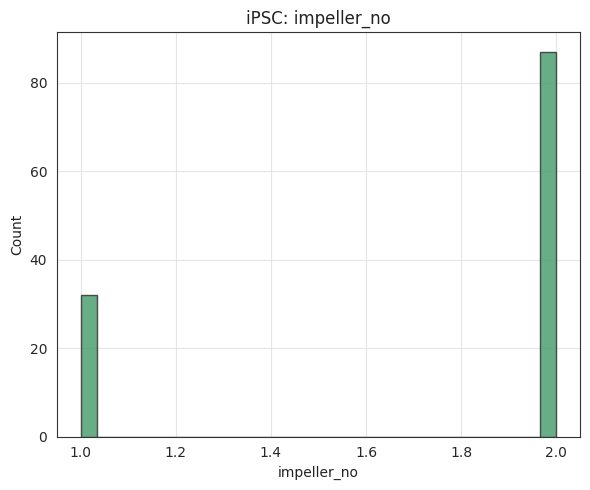

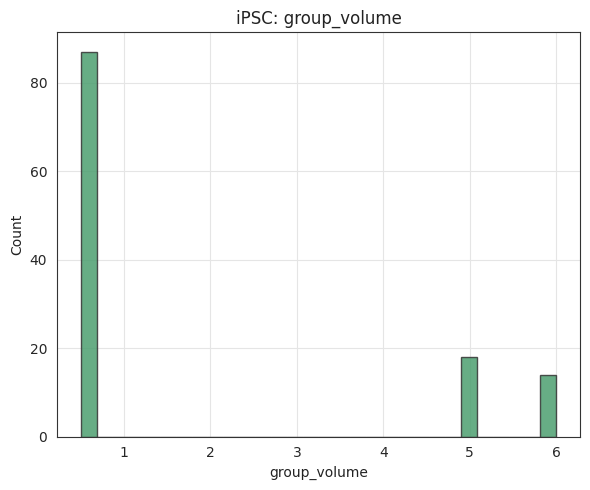

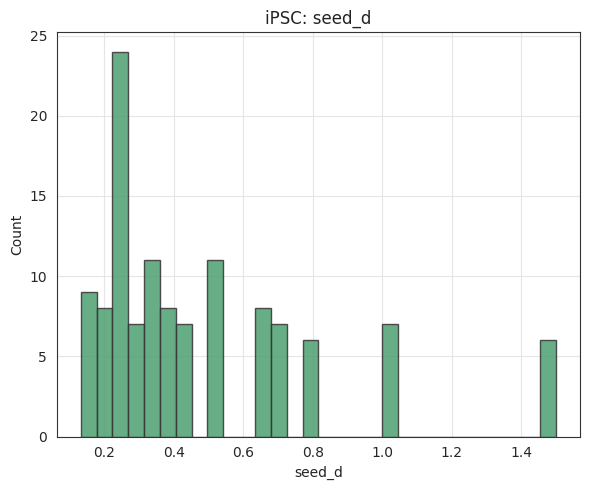

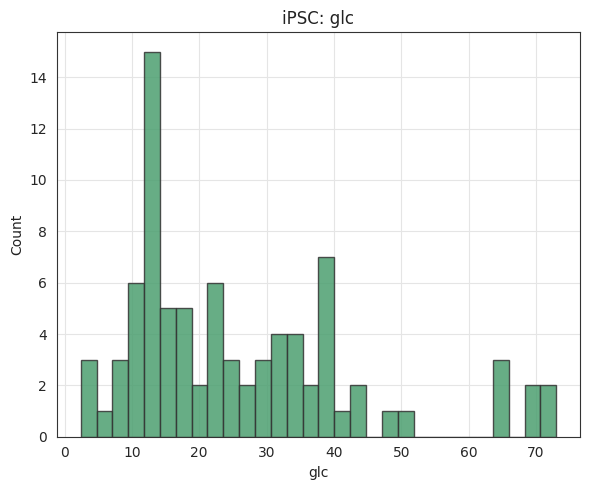

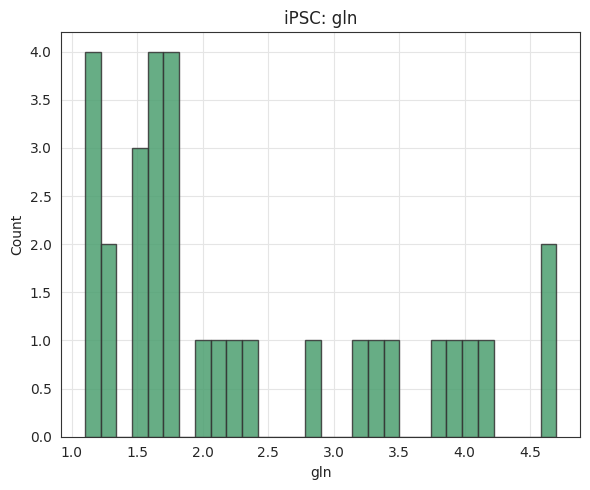

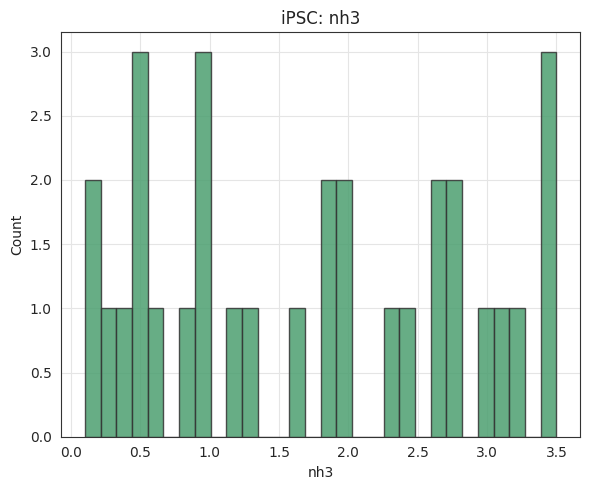

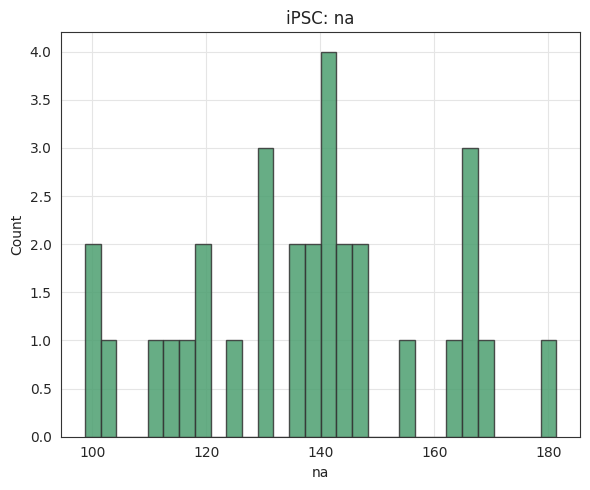

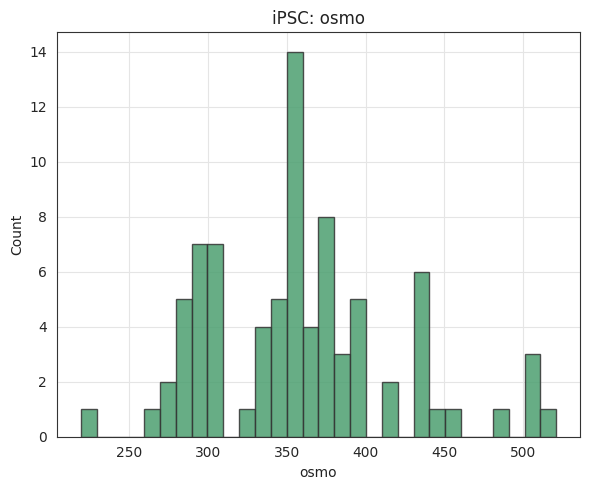

In [ ]:
for column in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6, 5))
    plt.hist(df[column].dropna(),
        bins=30,
        color=colours['hist_bar'],
        edgecolor=colours['axes'],
        alpha=0.85
    )
    plt.title(f'iPSC: {column}', color=colours['text'])
    plt.xlabel(column, color=colours['text'])
    plt.ylabel('Count', color=colours['text'])
    plt.grid(True, axis='y', color=colours['grid'])
    plt.tight_layout()

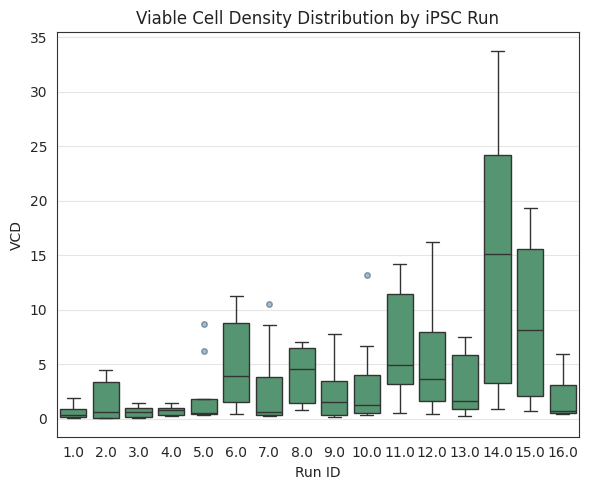

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(
    x='r_id',
    y='vcd',
    data=df,
    color=colours['hist_bar'],
    boxprops=dict(edgecolor=colours['axes']),
    medianprops=dict(color=colours['axes']),
    whiskerprops=dict(color=colours['axes']),
    capprops=dict(color=colours['axes']),
    flierprops=dict(marker='o', markerfacecolor=colours['line_model'], alpha=0.5, markersize=4)
)
plt.xlabel('Run ID', color=colours['text'])
plt.ylabel('VCD', color=colours['text'])
plt.title('Viable Cell Density Distribution by iPSC Run', color=colours['text'])
plt.grid(True, axis='y', color=colours['grid'], linewidth=0.8)
plt.tight_layout()

Runs 6,8, 14 and 15 exhibit substantially higher VCDs compared to other runs, indicating improved growth performance on bigger 5L-6L scale.
Another runs show lower and more consistent VCD distributions, suggesting stable but less productive cultures (excluding 11 and 12).

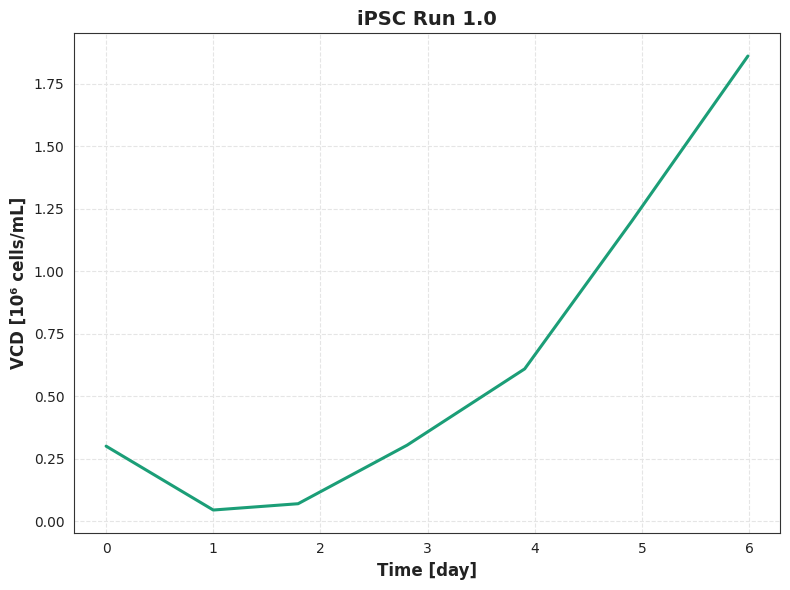

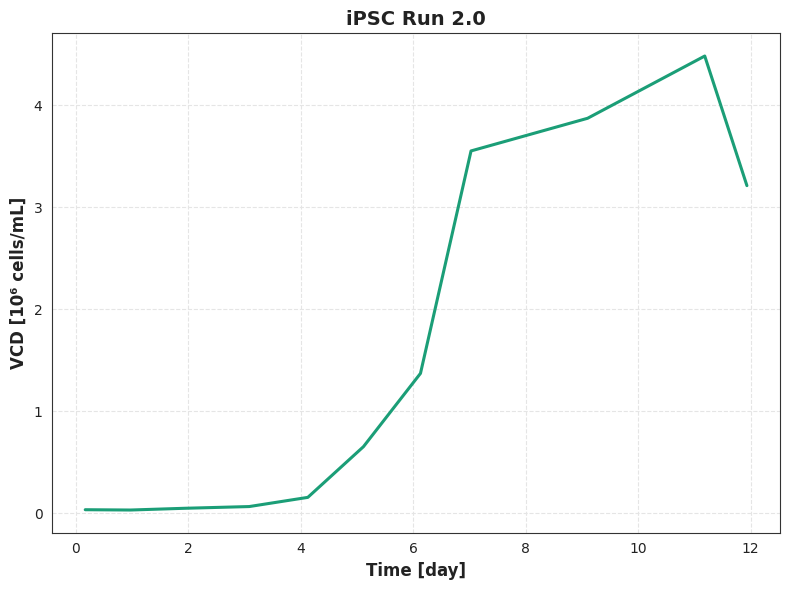

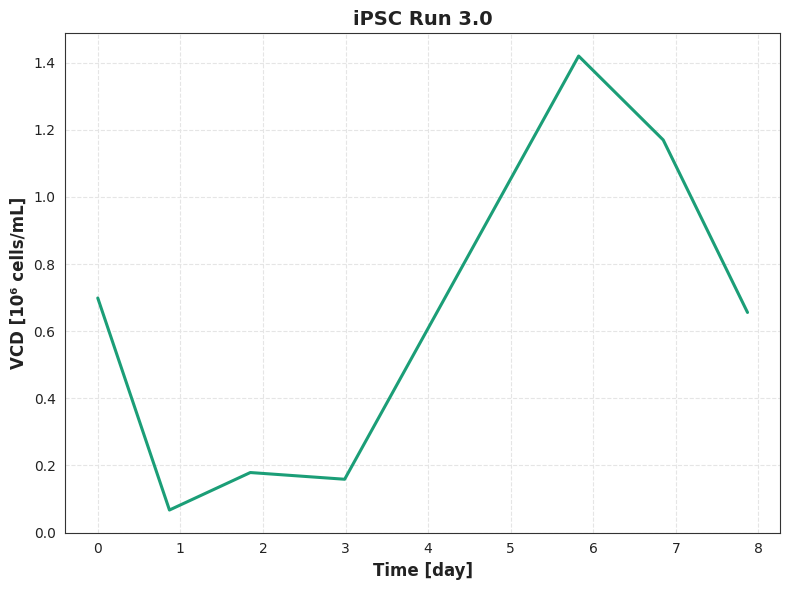

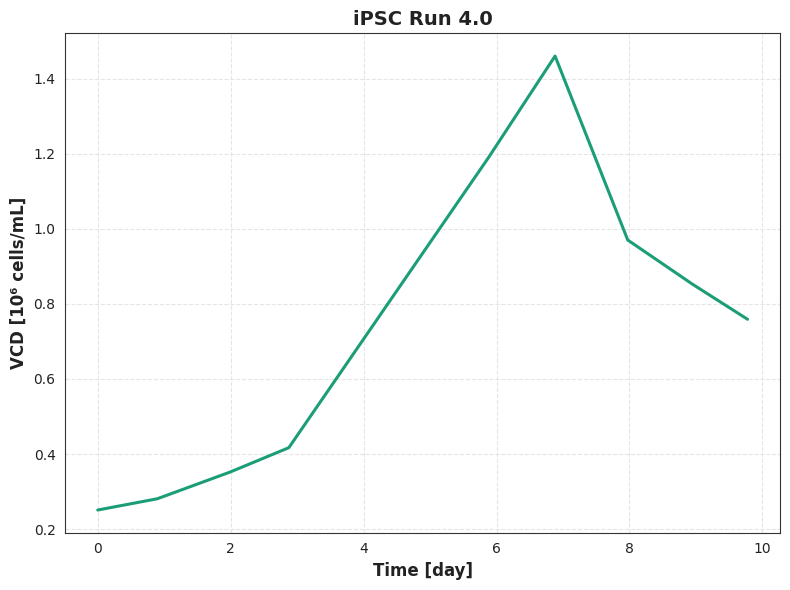

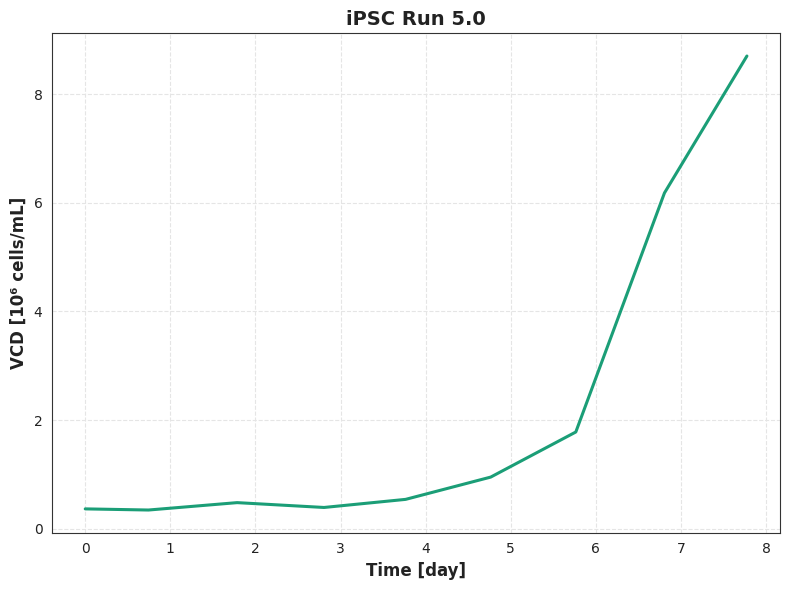

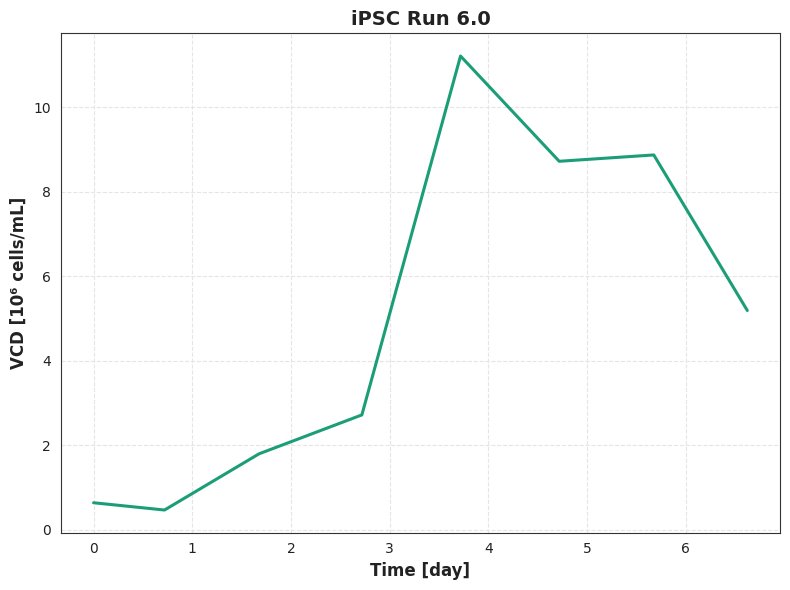

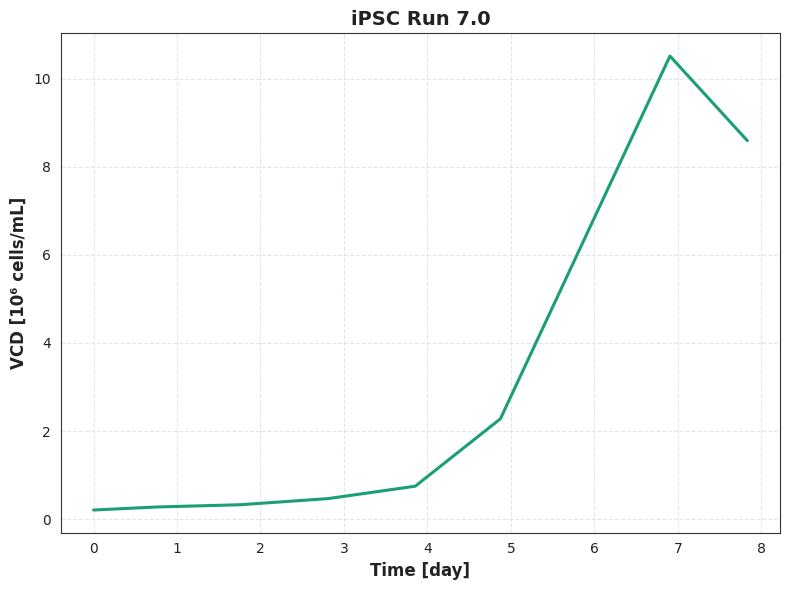

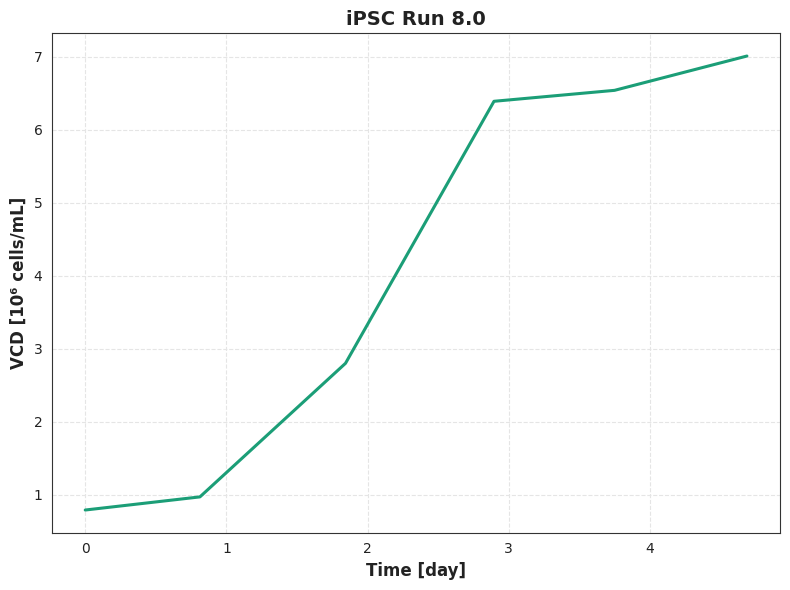

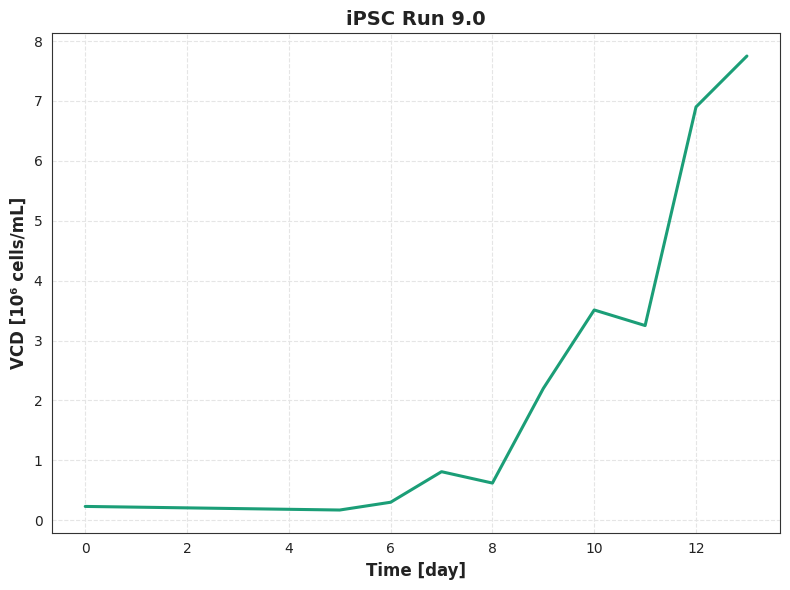

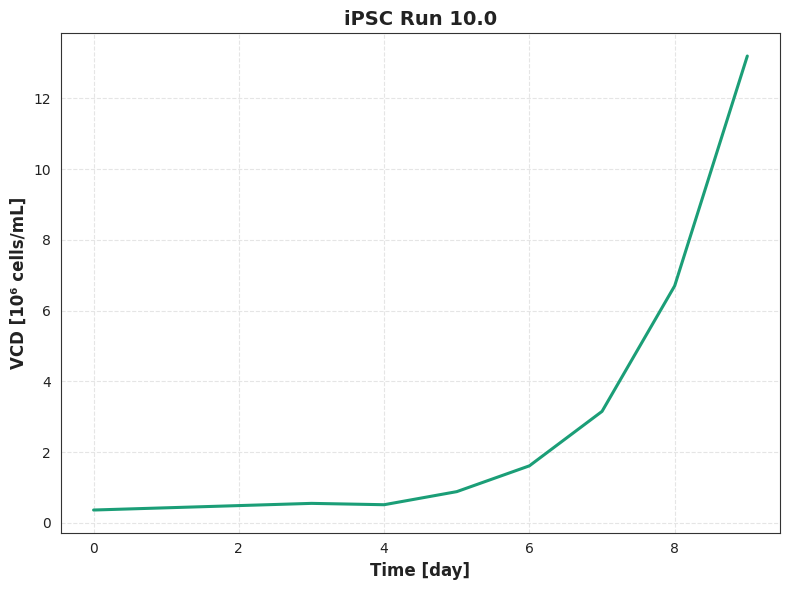

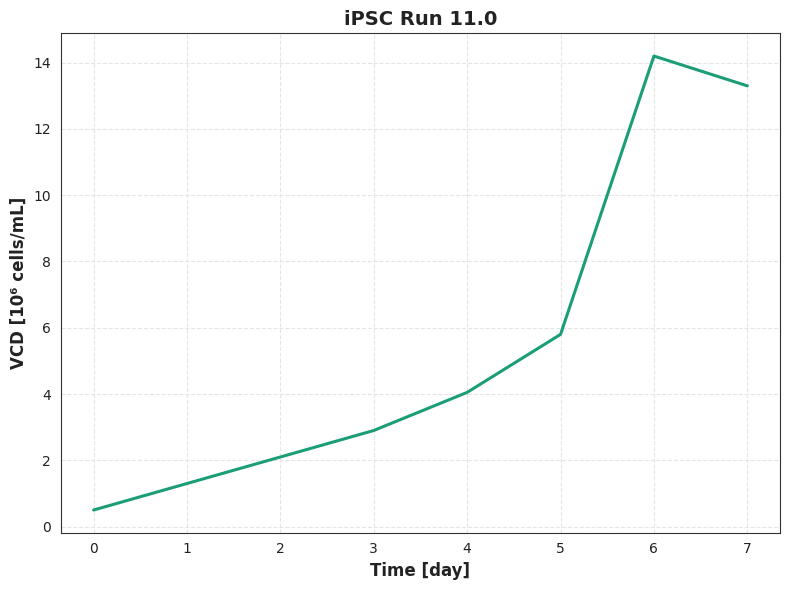

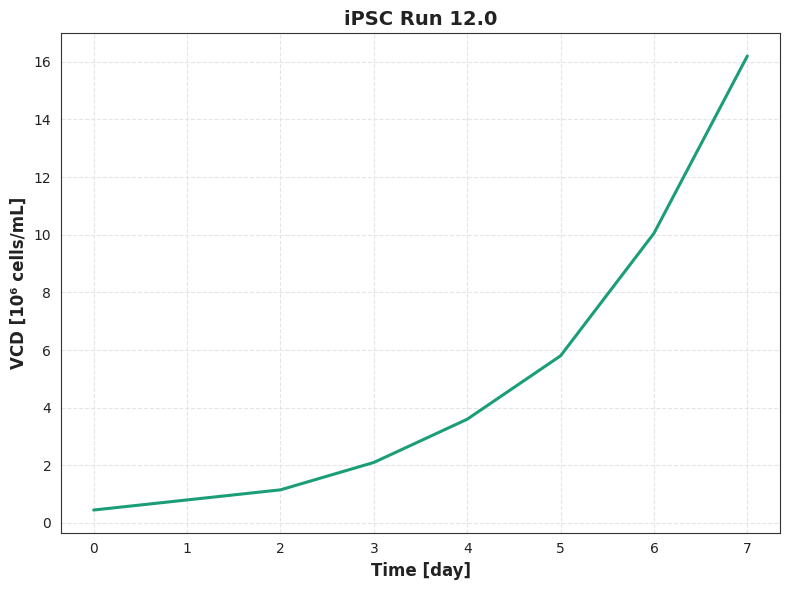

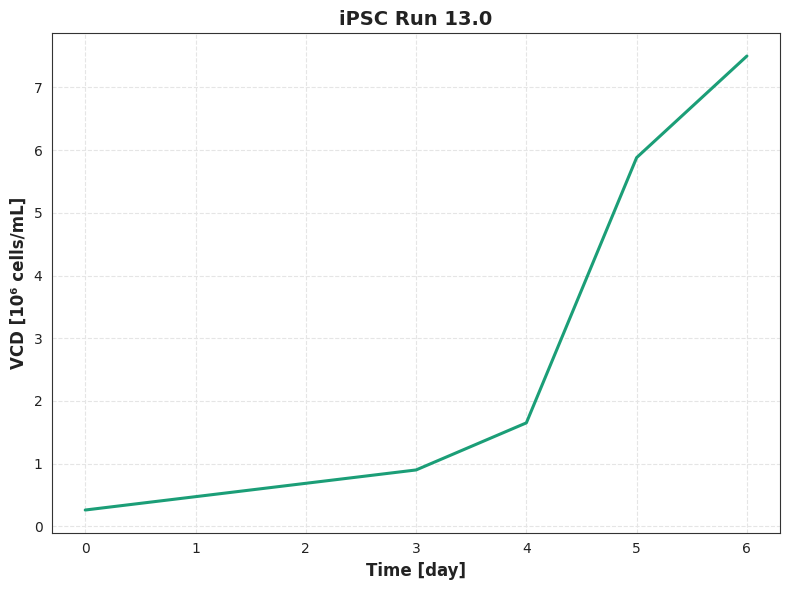

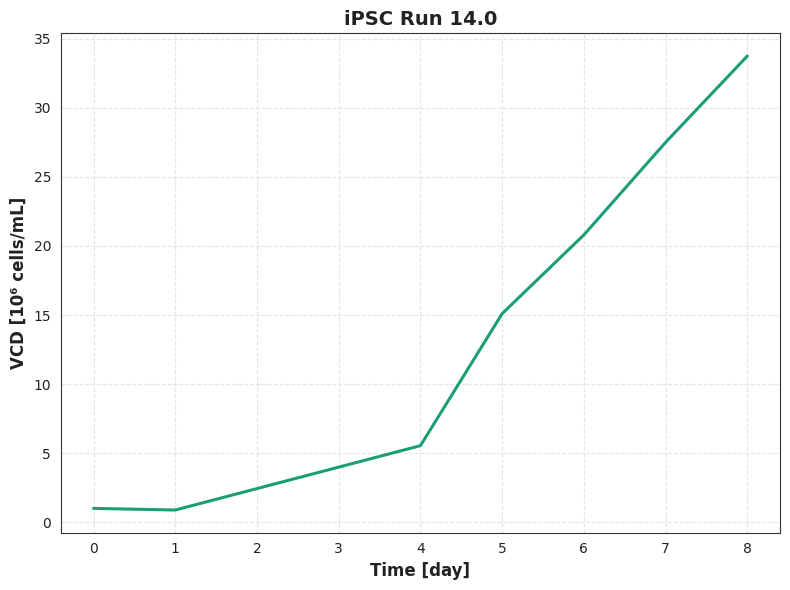

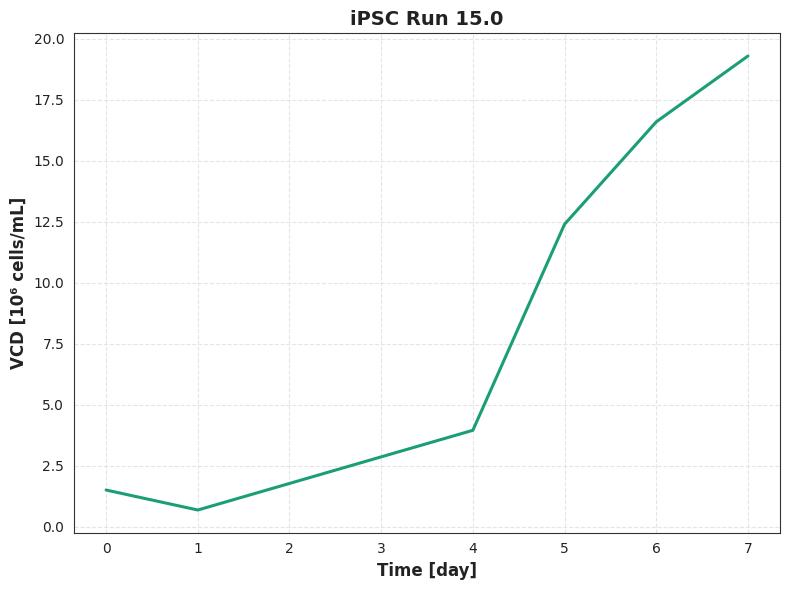

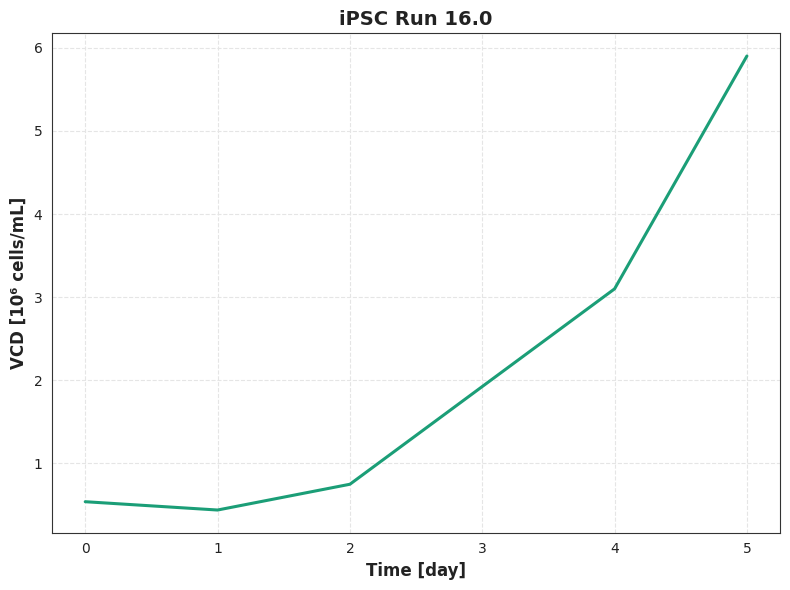

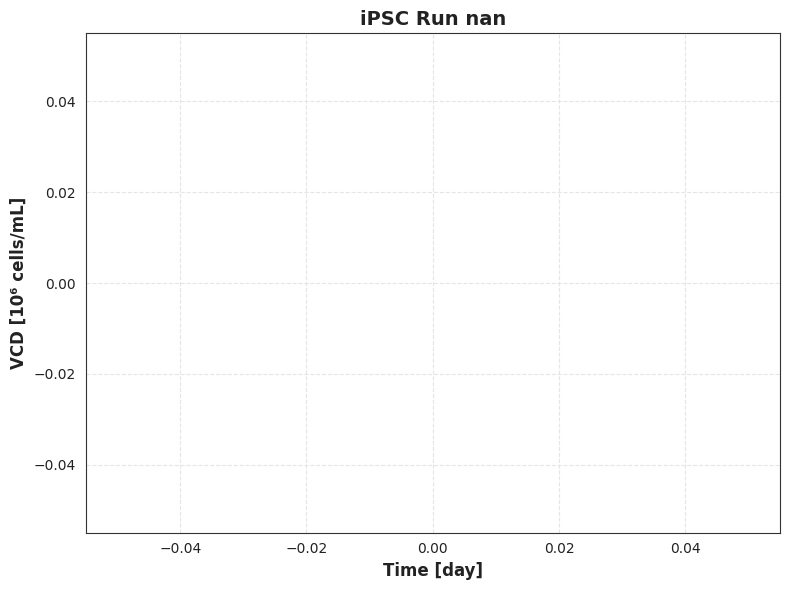

In [ ]:
for run in df['r_id'].unique():
    plt.figure(figsize=(8, 6))

    sns.lineplot(
        data=df[df['r_id'] == run],
        x='time', y='vcd',
        color=colours['line_exp'],
        linewidth=2.2,
        errorbar=None
    )

    plt.title(f'iPSC Run {run}', fontsize=14, fontweight='bold', color=colours['text'])
    plt.xlabel('Time [day]', fontsize=12, fontweight='bold', color=colours['text'])
    plt.ylabel('VCD [10⁶ cells/mL]', fontsize=12, fontweight='bold', color=colours['text'])

    plt.grid(True, color=colours['grid'], linestyle='--', linewidth=0.8)
    plt.gca().set_facecolor(colours['background'])
    plt.tick_params(colors=colours['text'])
    plt.tight_layout()

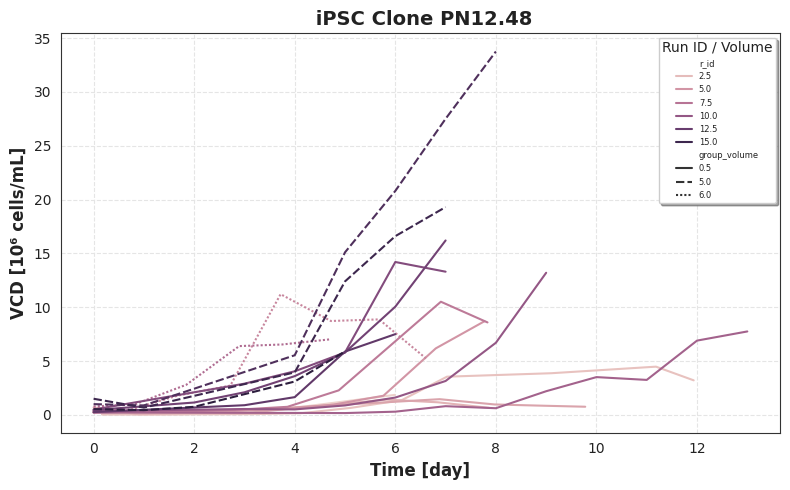

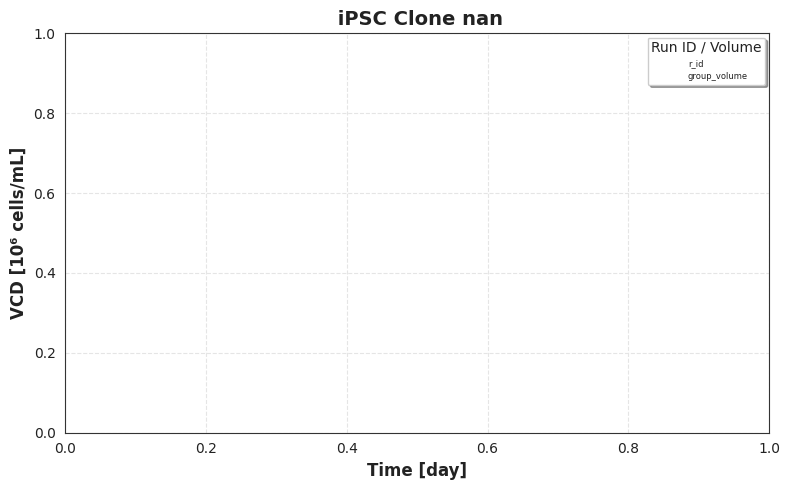

In [ ]:
for clone in df['clone_id'].unique():
    plt.figure(figsize=(8, 5))

    sns.lineplot(
        data=df[df['clone_id'] == clone],
        x='time', y='vcd',
        hue='r_id',
        style='group_volume',
        errorbar=None
    )

    plt.title(f' iPSC Clone {clone}', fontsize=14, fontweight='bold', color=colours["text"])
    plt.xlabel('Time [day]', fontsize=12, fontweight='bold', color=colours["text"])
    plt.ylabel('VCD [10⁶ cells/mL]', fontsize=12, fontweight='bold', color=colours["text"])

    plt.legend(title='Run ID / Volume', fontsize=6, frameon=True, shadow=True)
    plt.grid(True, color=colours["grid"], linestyle='--', linewidth=0.8)
    plt.gca().set_facecolor(colours["background"])
    plt.tick_params(colors=colours["text"])
    plt.tight_layout()

Text(0.5, 1.0, 'Correlation Heatmap iPSC')

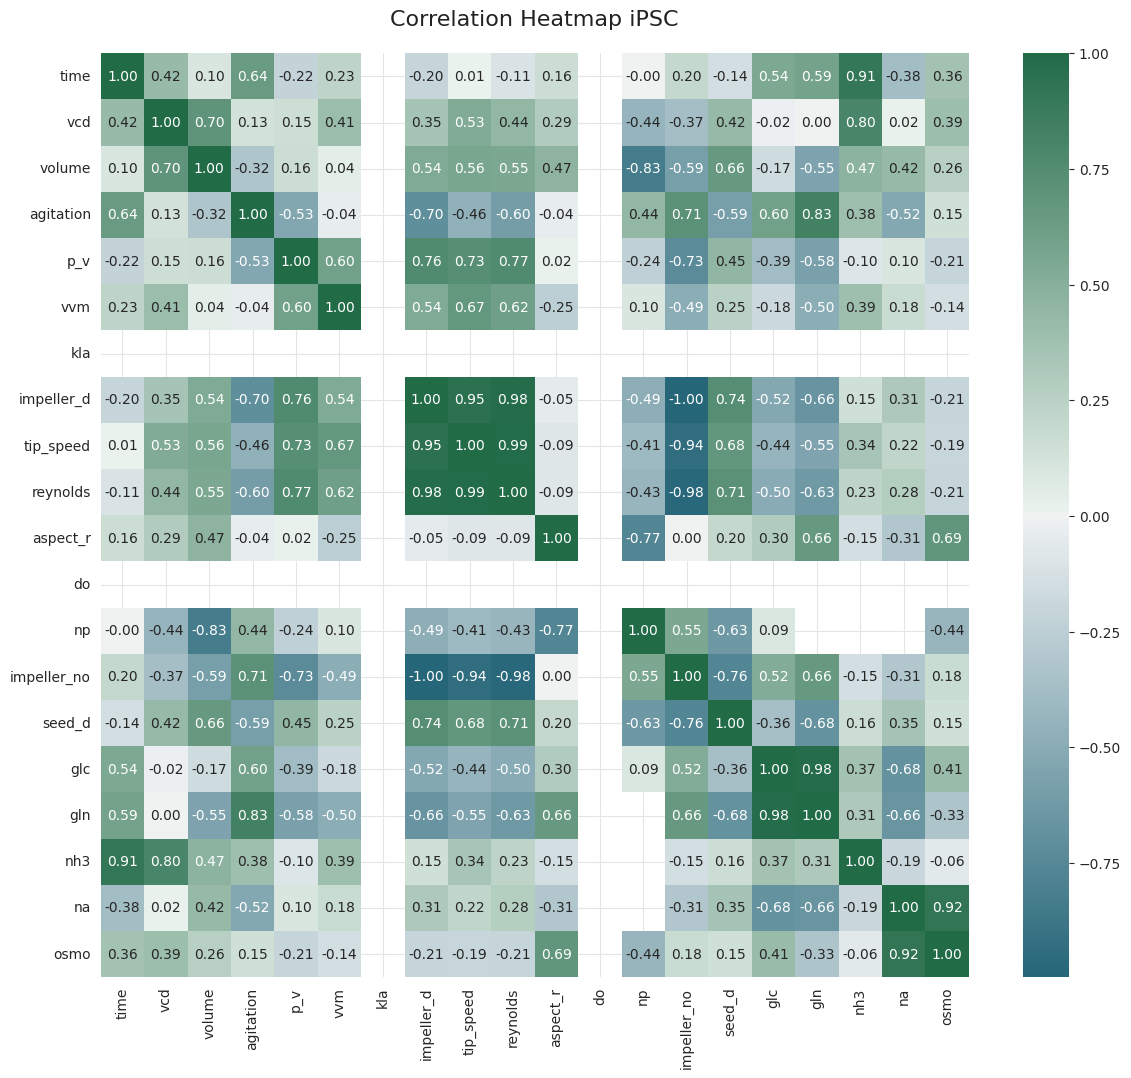

In [ ]:
numeric_df = df.select_dtypes(include=['number']).drop(columns=['p_id', 'r_id', 'group_volume' ])
corr = numeric_df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap=sns.diverging_palette(220, 145, s=85, l=40, as_cmap=True),
    annot=True,
    fmt='.2f'
)
plt.title('Correlation Heatmap iPSC', fontsize=16, pad=20)

missing values

In [ ]:
df.drop(columns=['kla', 'impeller_d', 'np', 'do', 'impeller_no', 'agitation'], inplace=True)

In [ ]:
df = df.dropna(subset=['vcd', 'time'])

In [ ]:
df = df.dropna(subset=['volume'])

In [ ]:
df.isnull().sum()

,0
vessel,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
p_v,0
vvm,0
tip_speed,0


In [ ]:
df.drop(columns=['vessel', 'glc', 'gln', 'nh3', 'lac', 'na', 'osmo'], inplace=True)

In [ ]:
df.isnull().sum()

,0
p_id,0
r_id,0
clone_id,0
time,0
vcd,0
volume,0
p_v,0
vvm,0
tip_speed,0
reynolds,0


In [ ]:
train1_df_ipsc = df[df['r_id'].isin([1, 2, 3, 4, 9, 10, 11, 13])].copy()
train1_df_ipsc.reset_index(drop=True, inplace=True)
train2_df_ipsc = df[df['r_id'].isin([6, 14])].copy()
train2_df_ipsc.reset_index(drop=True, inplace=True)

In [ ]:
val1_df_ipsc = df[df['r_id'].isin([5, 7, 12])].copy()
val1_df_ipsc.reset_index(drop=True, inplace=True)
val2_df_ipsc = df[df['r_id'].isin([15])].copy()
val2_df_ipsc.reset_index(drop=True, inplace=True)

In [ ]:
test_df_ipsc = df[df['r_id'].isin([8, 16])].copy()
test_df_ipsc.reset_index(drop=True, inplace=True)

In [ ]:
train1_df_ipsc.to_csv('train1_df_ipsc.csv', index=False)
val1_df_ipsc.to_csv('val1_df_ipsc.csv', index=False)
train2_df_ipsc.to_csv('train2_df_ipsc.csv', index=False)
val2_df_ipsc.to_csv('val2_df_ipsc.csv', index=False)
test_df_ipsc.to_csv('test_df_ipsc.csv', index=False)

In [ ]:
files.download('train1_df_ipsc.csv')
files.download('val1_df_ipsc.csv')
files.download('train2_df_ipsc.csv')
files.download('val2_df_ipsc.csv')
files.download('test_df_ipsc.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>